In [5]:
# Cell 1: Imports and connection setup
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.db import get_connection

con = get_connection(read_only=True)
print("Connected (read-only) — ready for investigation")

Connected (read-only) — ready for investigation


#### Opening -- How much money leaked and where? 

In [6]:
# Opening: Total denied dollars and denial rate
result = con.execute("""
    SELECT
        COUNT(*)                                                              AS total_lines,
        SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                  AND paid_amount = 0 THEN 1 ELSE 0 END)                     AS denied_lines,
        ROUND(100.0 * SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                               AND paid_amount = 0 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                                  AS denial_rate_pct,
        ROUND(SUM(paid_amount + patient_responsibility + adjustment_amount), 2) AS total_billed,
        ROUND(SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                        AND paid_amount = 0
                       THEN adjustment_amount ELSE 0 END), 2)                AS total_denied_dollars
    FROM remittance_835
""").df()

print(result.to_string(index=False))

 total_lines  denied_lines  denial_rate_pct  total_billed  total_denied_dollars
       69574       10089.0             14.5   88757319.06           12447775.58


In [7]:
# Opening: Net Collection Rate
result = con.execute("""
	SELECT
    ROUND(SUM(paid_amount) * 100.0 / SUM(allowed_amount), 2) AS net_collection_rate
FROM remittance_835
WHERE allowed_amount > 0
""").df()

print(result.to_string(index=False))

 net_collection_rate
               97.49


In [8]:
# Opening: Payer Breakdown
result = con.execute("""
    SELECT
    ch.payer_id,
    COUNT(r.remittance_id)                                      AS total_lines,
    SUM(CASE WHEN r.paid_amount = 0 THEN 1 ELSE 0 END)          AS denied_lines,
    ROUND(SUM(CASE WHEN r.paid_amount = 0 THEN 1 ELSE 0 END) 
          * 100.0 / COUNT(*), 1)                                 AS denial_rate_pct,
    SUM(CASE WHEN r.paid_amount = 0 
        THEN r.adjustment_amount ELSE 0 END)                     AS denied_dollars
FROM remittance_835 r
JOIN claim_header ch ON r.claim_id = ch.claim_id
WHERE r.carc_code NOT IN ('CO-45', 'PR-1')
GROUP BY ch.payer_id
ORDER BY denied_dollars DESC
""").df()

print(result.to_string(index=False))

              payer_id  total_lines  denied_lines  denial_rate_pct  denied_dollars
 medi_cal_managed_care         5059        5059.0            100.0      6400419.53
        commercial_ppo         2185        2185.0            100.0      2598705.27
    medicare_advantage         1823        1823.0            100.0      2172378.93
dual_eligible_cobpayer         1022        1022.0            100.0      1276271.85


-------
#### Chapter 1 -- The Upstream Investigation

In [9]:
# Chapter 1: Which nodes in the care-dollar chain failed
result = con.execute("""
	SELECT
    upstream_failure_node,
    COUNT(*)                          AS denial_count,
    SUM(dollars_at_risk)              AS total_at_risk,
    ROUND(SUM(dollars_at_risk) * 100.0 
          / SUM(SUM(dollars_at_risk)) OVER (), 1) AS pct_of_total,
    ROUND(AVG(recovery_probability), 3) AS avg_recovery_prob
FROM denial_forensics
GROUP BY upstream_failure_node
ORDER BY total_at_risk DESC
""").df()

print(result.to_string(index=False))

upstream_failure_node  denial_count  total_at_risk  pct_of_total  avg_recovery_prob
  prior_authorization          2040     4890631.54          39.3              0.476
               coding          3910     4818146.82          38.7              0.692
              billing          1591     1680743.15          13.5              0.720
   remittance_posting           595      765555.38           6.2              0.550
        credentialing          1505      212264.86           1.7              0.150
       charge_capture           448       80433.83           0.6              0.100


In [10]:
# Chapter 1: Preventable & Nonpreventable Split
result = con.execute("""
	SELECT
    preventability_flag,
    COUNT(*)             AS denial_count,
    SUM(dollars_at_risk) AS dollars_at_risk,
    ROUND(SUM(dollars_at_risk) * 100.0 
          / SUM(SUM(dollars_at_risk)) OVER (), 1) AS pct_of_total
FROM denial_forensics
GROUP BY preventability_flag
""").df()

print(result.to_string(index=False))

 preventability_flag  denial_count  dollars_at_risk  pct_of_total
               False           759       1903690.02          15.3
                True          9330      10544085.56          84.7


In [11]:
# Chapter 1: Preventable denials mapped to failure node
result = con.execute("""
	SELECT
    upstream_failure_node,
    COUNT(*)             AS denial_count,
    SUM(dollars_at_risk) AS addressable_dollars
FROM denial_forensics
WHERE preventability_flag = TRUE
GROUP BY upstream_failure_node
ORDER BY addressable_dollars DESC
""").df()

print(result.to_string(index=False))

upstream_failure_node  denial_count  addressable_dollars
               coding          3910           4818146.82
  prior_authorization          1281           2986941.52
              billing          1591           1680743.15
   remittance_posting           595            765555.38
        credentialing          1505            212264.86
       charge_capture           448             80433.83


---------
#### Chapter 2 -- The Actor Analysis; Is this a provider problem or a payer problem?

In [13]:
# Chapter 2: Top CARC Code per Provider
result = con.execute("""
    SELECT
        p.persona_type,
        r.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM remittance_835 r
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    JOIN denial_forensics df ON r.claim_line_id = df.claim_line_id
    WHERE r.paid_amount = 0
      AND r.carc_code NOT IN ('CO-45', 'PR-1')
    GROUP BY p.persona_type, r.carc_code
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY p.persona_type
        ORDER BY COUNT(*) DESC
    ) = 1
    ORDER BY dollars_at_risk DESC
""").df()

print(result.to_string(index=False))

             persona_type carc_code  denial_count  dollars_at_risk
medical_necessity_denials     CO-57           600       2552387.36
            coding_errors      CO-4          1228       1553466.78
          prior_auth_miss     CO-57           681        434554.16
     credentialing_errors     CO-B7          1505        212264.86
      slow_charge_capture      CO-4           451         79285.17


Provider × Failure Node — Denial Dollars

          practice_name              persona_type upstream_failure_node  denial_count  dollars_at_risk
Behavioral Health Group      credentialing_errors         credentialing          1505        212264.86
Behavioral Health Group      credentialing_errors                coding           976        139194.97
Behavioral Health Group      credentialing_errors               billing           304         40595.44
Behavioral Health Group      credentialing_errors    remittance_posting           112         15185.32
        Emergency Group             coding_errors                coding          1373       1746327.21
        Emergency Group             coding_errors               billing           745        916103.49
        Emergency Group             coding_errors    remittance_posting           110        142548.21
        Emergency Group             coding_errors   prior_authorization             2          2040.39
Internal Medicine Group       s

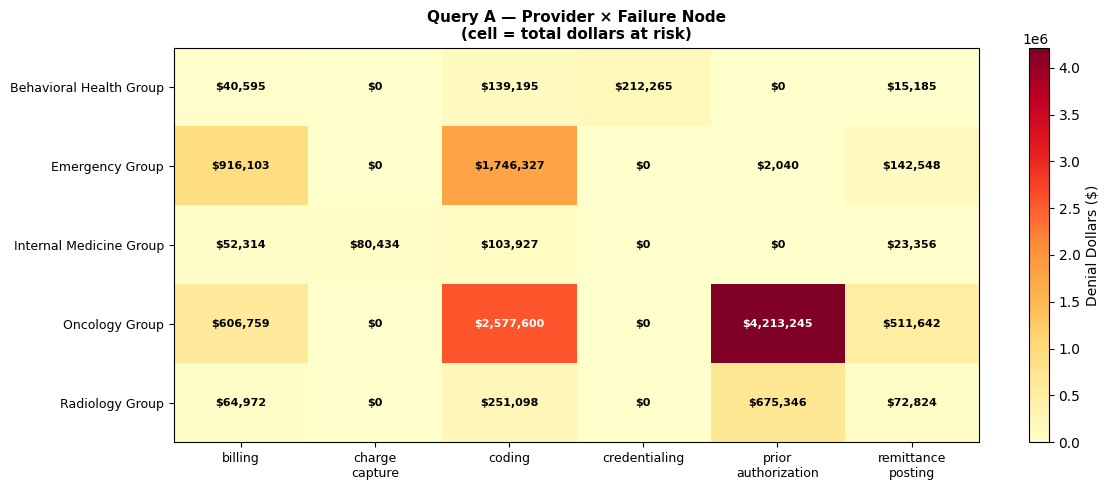

In [2]:
# Provider × Failure Node 
# Which providers are the biggest dollar source for each failure type?
 
provider_node = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        df.upstream_failure_node,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type, df.upstream_failure_node
    ORDER BY p.practice_name, dollars_at_risk DESC
""").df()
 
print("Provider × Failure Node — Denial Dollars\n")
print(provider_node.to_string(index=False))
 
# Heatmap
pivot_a = provider_node.pivot_table(
    index="practice_name",
    columns="upstream_failure_node",
    values="dollars_at_risk",
    aggfunc="sum"
).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_a.values, cmap="YlOrRd", aspect="auto")
 
ax.set_xticks(range(len(pivot_a.columns)))
ax.set_xticklabels([c.replace("_", "\n") for c in pivot_a.columns], fontsize=9)
ax.set_yticks(range(len(pivot_a.index)))
ax.set_yticklabels(pivot_a.index, fontsize=9)
 
vmax = pivot_a.values.max()
for i in range(len(pivot_a.index)):
    for j in range(len(pivot_a.columns)):
        val = pivot_a.values[i, j]
        color = "white" if val > vmax * 0.6 else "black"
        ax.text(j, i, f"${val:,.0f}", ha="center", va="center",
                fontsize=8, fontweight="bold", color=color)
 
plt.colorbar(im, ax=ax, label="Denial Dollars ($)")
ax.set_title("Query A — Provider × Failure Node\n(cell = total dollars at risk)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

Payer × Failure Node — Denial Dollars

              payer_id upstream_failure_node  denial_count  dollars_at_risk
        commercial_ppo                coding          1021       1376026.81
        commercial_ppo   prior_authorization           269        706129.87
        commercial_ppo               billing           440        449939.80
        commercial_ppo         credentialing           455         66608.79
dual_eligible_cobpayer    remittance_posting           595        765555.38
dual_eligible_cobpayer                coding           172        242256.76
dual_eligible_cobpayer   prior_authorization            56        138707.22
dual_eligible_cobpayer               billing            88        112514.38
dual_eligible_cobpayer         credentialing            74         10920.73
dual_eligible_cobpayer        charge_capture            37          6317.38
 medi_cal_managed_care   prior_authorization          1342       3184547.26
 medi_cal_managed_care                coding     

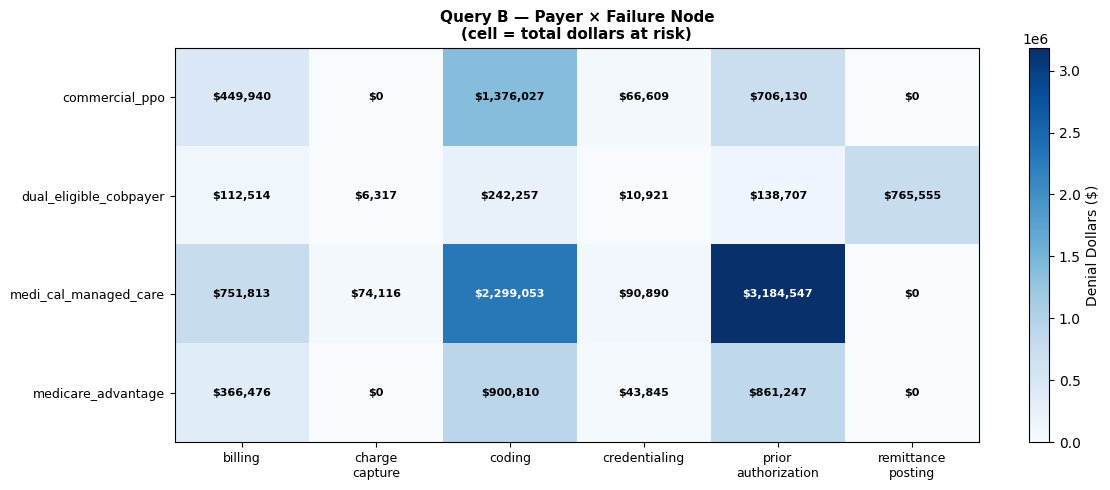

In [3]:
# Payer × Failure Node 
# Which payers are creating the most denial dollars at each failure node?
 
payer_node = con.execute("""
    SELECT
        ch.payer_id,
        df.upstream_failure_node,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    GROUP BY ch.payer_id, df.upstream_failure_node
    ORDER BY ch.payer_id, dollars_at_risk DESC
""").df()
 
print("Payer × Failure Node — Denial Dollars\n")
print(payer_node.to_string(index=False))
 
# Heatmap
pivot_b = payer_node.pivot_table(
    index="payer_id",
    columns="upstream_failure_node",
    values="dollars_at_risk",
    aggfunc="sum"
).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_b.values, cmap="Blues", aspect="auto")
 
ax.set_xticks(range(len(pivot_b.columns)))
ax.set_xticklabels([c.replace("_", "\n") for c in pivot_b.columns], fontsize=9)
ax.set_yticks(range(len(pivot_b.index)))
ax.set_yticklabels(pivot_b.index, fontsize=9)
 
vmax_b = pivot_b.values.max()
for i in range(len(pivot_b.index)):
    for j in range(len(pivot_b.columns)):
        val = pivot_b.values[i, j]
        color = "white" if val > vmax_b * 0.6 else "black"
        ax.text(j, i, f"${val:,.0f}", ha="center", va="center",
                fontsize=8, fontweight="bold", color=color)
 
plt.colorbar(im, ax=ax, label="Denial Dollars ($)")
ax.set_title("Query B — Payer × Failure Node\n(cell = total dollars at risk)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

Query C — Provider + Payer Combined: Top 20 by Denial Dollars

  practice_name              persona_type               payer_id upstream_failure_node carc_code  denial_count  dollars_at_risk  avg_recovery_prob  expected_recoverable
 Oncology Group medical_necessity_denials  medi_cal_managed_care   prior_authorization     CO-57           381       1645542.82               0.55             905048.55
 Oncology Group medical_necessity_denials  medi_cal_managed_care   prior_authorization     CO-50           256       1081779.55               0.35             378622.84
 Oncology Group medical_necessity_denials  medi_cal_managed_care                coding      CO-4           211        854842.13               0.70             598389.49
 Oncology Group medical_necessity_denials         commercial_ppo                coding      CO-4           164        752104.43               0.70             526473.10
Emergency Group             coding_errors  medi_cal_managed_care                coding      

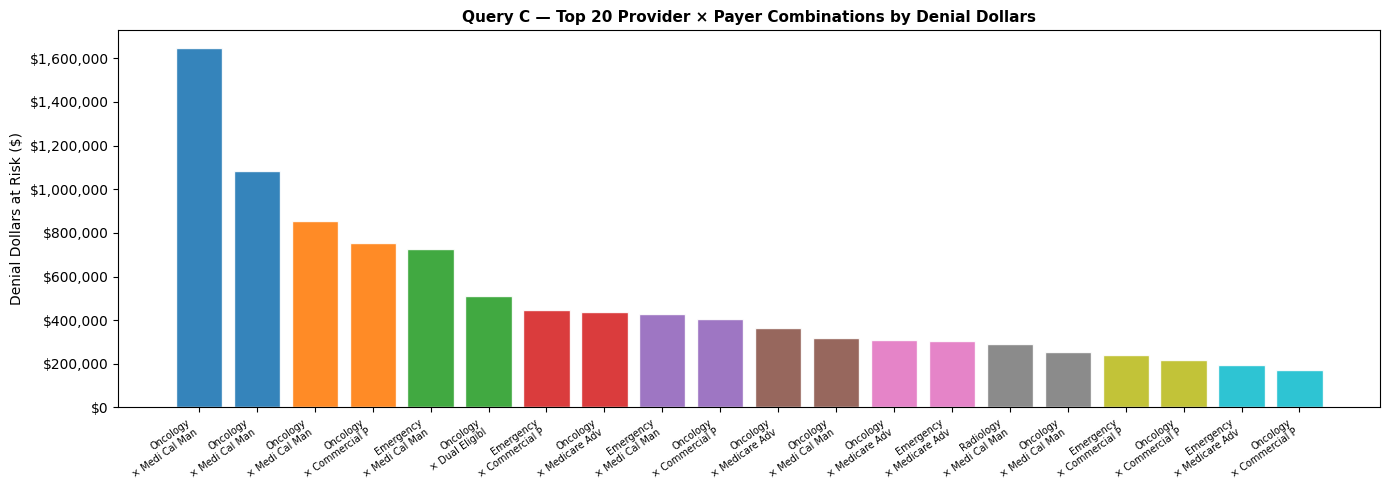

In [6]:
# Provider + Payer Combined
# Where provider failure mode and payer behavior intersect.
# The highest-dollar rows in this table are the specific meetings to call.
 
provider_payer = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        ch.payer_id,
        df.upstream_failure_node,
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type, ch.payer_id,
             df.upstream_failure_node, df.carc_code
    ORDER BY dollars_at_risk DESC
""").df()
 
print("Query C — Provider + Payer Combined: Top 20 by Denial Dollars\n")
print(provider_payer.head(20).to_string(index=False))
 
# Grouped bar: top provider-payer combinations by dollars at risk
top20 = provider_payer.head(20).copy()
top20["label"] = top20["practice_name"].str.replace(" Group", "") + "\n× " + \
                 top20["payer_id"].str.replace("_", " ").str.title().str[:12]
 
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top20)))
bars = ax.bar(range(len(top20)), top20["dollars_at_risk"],
              color=colors, edgecolor="white", alpha=0.9)
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20["label"], rotation=35, ha="right", fontsize=7)
ax.set_ylabel("Denial Dollars at Risk ($)")
ax.set_title("Query C — Top 20 Provider × Payer Combinations by Denial Dollars",
             fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()
plt.show()

Query D — Payer → CPT Denial Profile

              payer_id cpt_code carc_code  denial_count  dollars_at_risk
        commercial_ppo    99213      CO-4           526        703926.96
        commercial_ppo    99213     CO-57           102        275919.69
        commercial_ppo    99213     CO-16           256        275201.49
        commercial_ppo    99213     CO-50            45        125251.68
        commercial_ppo    45378      CO-4            61        120074.68
        commercial_ppo    95117      CO-4            60         97598.57
        commercial_ppo    96372      CO-4            50         82221.86
        commercial_ppo    45378     CO-97            65         75719.72
        commercial_ppo    95004      CO-4            32         55298.28
        commercial_ppo    81025      CO-4            25         39647.22
        commercial_ppo    94010      CO-4            34         38934.89
        commercial_ppo    99213     CO-B7           248         37555.43
        comme

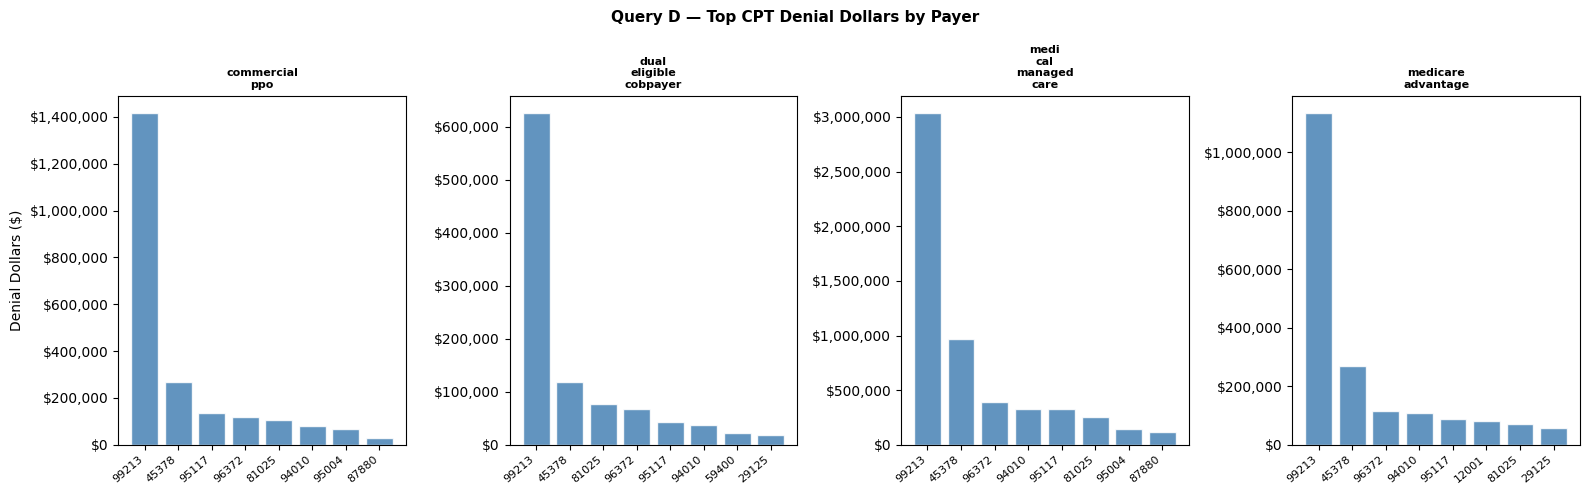

In [7]:
# Payer → CPT Profile 
# For each payer: which CPT codes are generating the most denial dollars?
# Grouped by payer first, then by CPT — shows payer-specific denial behavior.
 
payer_cpt = con.execute("""
    SELECT
        ch.payer_id,
        cl.cpt_code,
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN claim_line cl    ON r.claim_line_id = cl.claim_line_id
    GROUP BY ch.payer_id, cl.cpt_code, df.carc_code
    HAVING COUNT(*) >= 5
    ORDER BY ch.payer_id, dollars_at_risk DESC
""").df()
 
print("Query D — Payer → CPT Denial Profile\n")
print(payer_cpt.to_string(index=False))
 
# Faceted: one panel per payer, top CPTs by dollars
payers = payer_cpt["payer_id"].unique()
fig, axes = plt.subplots(1, len(payers), figsize=(16, 5), sharey=False)
if len(payers) == 1:
    axes = [axes]
 
for ax, payer in zip(axes, payers):
    subset = (payer_cpt[payer_cpt["payer_id"] == payer]
              .groupby("cpt_code")["dollars_at_risk"]
              .sum()
              .sort_values(ascending=False)
              .head(8))
    if subset.empty:
        ax.set_visible(False)
        continue
    bars = ax.bar(range(len(subset)), subset.values,
                  color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset.index, rotation=40, ha="right", fontsize=8)
    ax.set_title(payer.replace("_", "\n"), fontsize=8, fontweight="bold")
    ax.set_ylabel("Denial Dollars ($)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
 
fig.suptitle("Query D — Top CPT Denial Dollars by Payer", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Chapter 2: Denial rate by provider persona
result = con.execute("""
    SELECT
        p.persona_type,
        p.specialty,
        COUNT(r.remittance_id)                                      AS total_lines,
        SUM(CASE WHEN r.paid_amount = 0 THEN 1 ELSE 0 END)          AS denied_lines,
        ROUND(SUM(CASE WHEN r.paid_amount = 0 THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 1)                                 AS denial_rate_pct,
        ROUND(SUM(CASE WHEN r.paid_amount = 0
              THEN r.adjustment_amount ELSE 0 END), 2)               AS denied_dollars
    FROM remittance_835 r
    JOIN claim_header ch ON r.claim_id = ch.claim_id
    JOIN provider p ON ch.provider_id = p.provider_id
    WHERE r.carc_code NOT IN ('CO-45', 'PR-1')
    GROUP BY p.persona_type, p.specialty
    ORDER BY denial_rate_pct DESC
""").df()

print(result.to_string(index=False))

             persona_type          specialty  total_lines  denied_lines  denial_rate_pct  denied_dollars
            coding_errors Emergency Medicine         2230        2230.0            100.0      2807019.30
      slow_charge_capture  Internal Medicine         1454        1454.0            100.0       260030.37
     credentialing_errors  Behavioral Health         2897        2897.0            100.0       407240.59
medical_necessity_denials           Oncology         1872        1872.0            100.0      7909245.58
          prior_auth_miss          Radiology         1636        1636.0            100.0      1064239.74


--------
#### Chapter 3 -- The Recovery Map

In [15]:
# Chapter 3: How much is still winnable, broken down by urgency
result = con.execute("""
    SELECT
        CASE 
            WHEN days_remaining_window <= 30  THEN '1. Critical  (≤30 days)'
            WHEN days_remaining_window <= 60  THEN '2. Urgent    (31-60 days)'
            WHEN days_remaining_window <= 90  THEN '3. Active    (61-90 days)'
            ELSE                                   '4. Standard  (90+ days)'
        END                                         AS urgency_tier,
        COUNT(*)                                    AS denial_count,
        ROUND(SUM(dollars_at_risk), 2)              AS dollars_at_risk,
        ROUND(AVG(recovery_probability), 3)         AS avg_recovery_prob,
        ROUND(SUM(dollars_at_risk 
              * recovery_probability), 2)           AS expected_recovery
    FROM denial_forensics
    WHERE days_remaining_window > 0
      AND recommended_action != 'write_off'
    GROUP BY urgency_tier
    ORDER BY urgency_tier
""").df()

print(result.to_string(index=True))

                urgency_tier  denial_count  dollars_at_risk  avg_recovery_prob  expected_recovery
0    1. Critical  (≤30 days)           115        135421.99              0.528           75826.35
1  2. Urgent    (31-60 days)            61         70149.29              0.567           40809.47
2    4. Standard  (90+ days)             1           204.57              0.650             132.97


In [16]:
# Chapter 3: Priority worklist — what to work first
result = con.execute("""
    SELECT
        df.carc_code,
        df.denial_category,
        df.upstream_failure_node,
        ROUND(df.dollars_at_risk, 2)        AS dollars_at_risk,
        df.days_remaining_window,
        df.recovery_probability,
        df.recommended_action,
        ROUND(df.priority_score, 4)         AS priority_score
    FROM denial_forensics df
    WHERE df.days_remaining_window > 0
      AND df.recommended_action != 'write_off'
    ORDER BY df.priority_score DESC
    LIMIT 25
""").df()

print(result.to_string(index=False))

carc_code     denial_category upstream_failure_node  dollars_at_risk  days_remaining_window  recovery_probability recommended_action  priority_score
     CO-4        coding_error                coding         11441.82                     13                  0.70   correct_resubmit      15440.1004
     CO-4        coding_error                coding          9446.81                      9                  0.70   correct_resubmit      12894.8956
    CO-57       authorization   prior_authorization         11536.02                     32                  0.55             appeal      11561.6556
    CO-57       authorization   prior_authorization         11738.42                     46                  0.55             appeal      11262.3619
    CO-57       authorization   prior_authorization          9698.64                     48                  0.55             appeal       9246.0368
    CO-97            bundling                coding          6852.95                      7               

In [17]:
# Chapter 3: Where should leadership focus process improvement effort?
result = con.execute("""
    SELECT
        upstream_failure_node,
        COUNT(*)                                              AS open_denials,
        ROUND(SUM(dollars_at_risk), 2)                        AS total_at_risk,
        ROUND(AVG(recovery_probability), 3)                   AS avg_recovery_prob,
        ROUND(SUM(dollars_at_risk 
              * recovery_probability), 2)                     AS expected_recovery,
        ROUND(AVG(days_remaining_window))                     AS avg_days_remaining
    FROM denial_forensics
    WHERE days_remaining_window > 0
      AND recommended_action != 'write_off'
    GROUP BY upstream_failure_node
    ORDER BY expected_recovery DESC
""").df()

print(result.to_string(index=False))

upstream_failure_node  open_denials  total_at_risk  avg_recovery_prob  expected_recovery  avg_days_remaining
               coding            73       82211.14              0.692           56834.08                21.0
  prior_authorization            35       97859.08              0.487           45354.41                23.0
              billing            19       13861.78              0.720            9980.48                33.0
   remittance_posting            18        7058.10              0.550            3881.96                35.0
        credentialing            32        4785.75              0.150             717.86                22.0


---------
#### Chapter 4 -- Model Validation

In [18]:
# Chapter 4: How did the appeals actually resolve?
result = con.execute("""
    SELECT
        carc_code,
        COUNT(*)                                                    AS total_appealed,
        SUM(CASE WHEN appeal_successful THEN 1 ELSE 0 END)          AS successful_appeals,
        ROUND(SUM(CASE WHEN appeal_successful THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 1)                                AS success_rate_pct,
        ROUND(SUM(dollars_at_risk), 2)                              AS total_at_risk,
        ROUND(SUM(dollars_recovered), 2)                            AS total_recovered,
        ROUND(AVG(days_to_resolve), 1)                              AS avg_days_to_resolve
    FROM appeal_outcomes
    GROUP BY carc_code
    ORDER BY total_at_risk DESC
""").df()

print(result.to_string(index=False))

carc_code  total_appealed  successful_appeals  success_rate_pct  total_at_risk  total_recovered  avg_days_to_resolve
     CO-4            3276              2269.0              69.3     3981335.76       2617784.18                 21.9
    CO-57            1281               613.0              47.9     2986941.52       1421049.18                 59.1
    CO-50             759               243.0              32.0     1903690.02        543044.48                 82.0
    CO-16            1591              1131.0              71.1     1680743.15       1094907.34                 14.6
    CO-97             634               400.0              63.1      836811.06        479931.44                 31.6
    CO-22             595               315.0              52.9      765555.38        373797.84                 31.8
    CO-B7            1505               224.0              14.9      212264.86         26884.82                 44.7


In [19]:
# Chapter 4: Predicted recovery probability vs actual success rate
result = con.execute("""
    SELECT
        ao.carc_code,
        COUNT(*)                                                    AS total_appeals,
        ROUND(AVG(ao.recovery_rate_est), 3)                         AS predicted_recovery,
        ROUND(AVG(ao.recovery_rate_act), 3)                         AS actual_recovery,
        ROUND(AVG(ao.recovery_rate_act) 
              - AVG(ao.recovery_rate_est), 3)                       AS calibration_error,
        ROUND(SUM(ao.dollars_recovered), 2)                         AS dollars_recovered
    FROM appeal_outcomes ao
    GROUP BY ao.carc_code
    ORDER BY ABS(AVG(ao.recovery_rate_act) - AVG(ao.recovery_rate_est))
""").df()

print(result.to_string(index=False))

carc_code  total_appeals  predicted_recovery  actual_recovery  calibration_error  dollars_recovered
    CO-B7           1505                0.15            0.134             -0.016           26884.82
    CO-50            759                0.35            0.289             -0.061          543044.48
    CO-22            595                0.55            0.478             -0.072          373797.84
     CO-4           3276                0.70            0.624             -0.076         2617784.18
    CO-16           1591                0.72            0.639             -0.081         1094907.34
    CO-97            634                0.65            0.562             -0.088          479931.44
    CO-57           1281                0.55            0.432             -0.118         1421049.18


In [20]:
# Chapter 4: Full calibration summary using appeal_outcomes module
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.appeal_outcomes import calibration_summary

appeal_df = con.execute("SELECT * FROM appeal_outcomes").df()

summary = calibration_summary(appeal_df)
print(summary.to_string(index=False))

carc_code  total_appeals  appeal_success_rate  avg_estimated_prob  calibration_error  total_at_risk  total_recovered  avg_days_to_resolve
    CO-16           1591                0.711                0.72             -0.081     1680743.15       1094907.34            14.578253
    CO-22            595                0.529                0.55             -0.072      765555.38        373797.84            31.815126
     CO-4           3276                0.693                0.70             -0.076     3981335.76       2617784.18            21.931929
    CO-50            759                0.320                0.35             -0.061     1903690.02        543044.48            81.974967
    CO-57           1281                0.479                0.55             -0.118     2986941.52       1421049.18            59.084309
    CO-97            634                0.631                0.65             -0.088      836811.06        479931.44            31.645110
    CO-B7           1505          